<a href="https://colab.research.google.com/github/roman-eyvazov/roman_projects/blob/main/Electricity_consumption_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Предсказание потребления электроэнергии города с помощью анализа временных рядов

**Постановка задачи**

Генерирующая компания стремится оптимизировать производство электроэнергии, основываясь на исторических данных о ее потреблении жителями города.

Данная проблема важна, поскольку при недостаточной генерации электроэнергии компания вынуждена покупать дополнительные мощности на оптовом рынке электроэнергии (ОРЭМ), при избыточной генерации — продавать на рынке дешевле, чем можно было бы продать городу.

Заказчик предоставил данные почасового анализа за 2023-2024 гг. Поставлена задача предсказывать почасовое потребление города на следующие трое суток (72 часа). Данные включают в себя временную метку, температуру воздуха (в градусах Цельсия), потребляемую мощность (в МВт).

Заказчик выдвинул требование обеспечить метрику MAPE (средняя абсолютная ошибка в процентах) на уровне не более 4%. На текущий момент ошибка прогнозирования может достигать 25%. При этом очевидно, что достижению высокой точности прогнозирования мешают непредвиденные или сложно предсказуемые события (например, авария на крупном промышленном предприятии). Но при этом заказчик предусмотрел в техническом задании «особенные дни», в которые допустима ошибка прогноза в 10%.

**Значение данных**

Этот набор данных может быть полезен для прогнозирования нагрузки и управления энергопотреблением. Анализируя эти данные, можно:

* разрабатывать точные модели краткосрочного и среднесрочного прогнозирования нагрузки;
* изучать влияние колебаний температуры на энергопотребление;
* анализировать циклические закономерности (внутрисуточные, недельные и сезонные колебания);
* оптимизировать распределение электроэнергии и ресурсов.

**План работы**

Поскольку наши данные представляют собой зависимость целевой переменной (потребления электроэнергии) от времени, то мы имеем дело с временным рядом (time series) — данными, последовательно собранными в регулярные промежутки времени. В отличие от обычных (перекрестных) данных, которые предполагают независимость наблюдений, во временных рядах будущее зависит от прошлого.

Работа с временными рядами предполагает два аспекта:

1. анализ временного ряда (time series analysis), т.е. понимание его структуры и закономерностей;
2. моделирование и построение прогноза на будущее (time series forecasting).

В соответствии с этим план работы выглядит так:

1. Исследовательский анализ данных (EDA) и визуализация временного ряда

На этом этапе необходимо выявяить все базовые закономерности, связанные с временными рядами, такие как тренд и сезонность.

2. Приведение временного ряда к стационарному виду

Стационарный временной ряд — это ряд, характеристики которого (среднее значение, дисперсия и т. д.), остаются постоянными во времени. Большинство методов статистического прогнозирования основаны на предположении, что временные ряды можно сделать приблизительно стационарными с помощью математических преобразований. Стационарный ряд относительно легко предсказать: можно считать, что его характеристики останутся в будущем такими же, как и в прошлом.

Стационарность (stationarity) временного ряда означает, что такие компоненты, как тренд и сезонность отсутствуют. Говоря более точно, среднее значение и дисперсия не меняются со смещением во времени.

Понимание того, стационарные ли у нас данные или нестационарные, важно для последующего моделирования.

3. Поиск оптимальных параметров модели

Необходимо найти оптимальные гиперпараметры для используемых моделей.

Для моделей семейства ARMA предварительные значения этих параметров берутся из графиков ACF (autocorrelation function) и PACF (partial autocorrelation function).

4. Прогнозирование

После нахождения оптимальных гиперпараметров мы можем делать прогнозы и оценивать полученные метрики.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

# 1. Первый взгляд на данные

In [ ]:
df_train = pd.read_csv('/content/train.csv')
df_test = pd.read_csv('/content/test.csv')

df_train.head()

,timestamp,temperature,is_holiday,load
0,2023-01-07 00:00:00,-6.4,0,4400.4
1,2023-01-07 01:00:00,-3.9,0,3738.7
2,2023-01-07 02:00:00,-4.5,0,3821.4
3,2023-01-07 03:00:00,-5.2,0,3891.1
4,2023-01-07 04:00:00,-1.7,0,3178.7


In [ ]:
df_test.head()

,timestamp,temperature,is_holiday,load
0,2024-12-17 00:00:00,-2.3,0,3355.2
1,2024-12-17 01:00:00,-5.7,0,4167.0
2,2024-12-17 02:00:00,-5.0,0,3930.4
3,2024-12-17 03:00:00,-4.4,0,3765.4
4,2024-12-17 04:00:00,-5.1,0,4093.9


In [ ]:
df_train.info()
print('-' * 50)
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17040 entries, 0 to 17039
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    17040 non-null  object 
 1   temperature  17040 non-null  float64
 2   is_holiday   17040 non-null  int64  
 3   load         17040 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 532.6+ KB
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    72 non-null     object 
 1   temperature  72 non-null     float64
 2   is_holiday   72 non-null     int64  
 3   load         72 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 2.4+ KB


In [ ]:
df_train.describe()

,temperature,is_holiday,load
count,17040.000000,17040.000000,17040.000000
mean,15.410053,0.026761,1770.651878
std,11.213387,0.161388,825.158694
min,-10.100000,0.000000,184.700000
25%,5.700000,0.000000,1168.400000
50%,15.600000,0.000000,1576.150000
75%,25.000000,0.000000,2185.725000
max,40.400000,1.000000,5456.800000


In [ ]:
df_test.describe()

,temperature,is_holiday,load
count,72.000000,72.0,72.000000
mean,-0.075000,0.0,3150.215278
std,4.271054,0.0,826.103510
min,-7.600000,0.0,1680.100000
25%,-3.750000,0.0,2513.575000
50%,0.350000,0.0,3087.900000
75%,3.025000,0.0,3713.200000
max,9.300000,0.0,4806.900000


In [ ]:
# пропусков нет
df_train.isnull().sum()

,0
timestamp,0
temperature,0
is_holiday,0
load,0


In [ ]:
df_test.isnull().sum()

,0
timestamp,0
temperature,0
is_holiday,0
load,0


In [ ]:
# дубликатов нет
df_train.duplicated().sum(), df_test.duplicated().sum()

(np.int64(0), np.int64(0))

# 2. EDA и первичная обработка данных


Преобразуем дату в объект datetime:

In [ ]:
df_train['timestamp'] = pd.to_datetime(df_train['timestamp'])
df_test['timestamp'] = pd.to_datetime(df_test['timestamp'])

Создадим новые признаки на основе дат. Также в датасет уже добавлен признак, показывающий, является ли день праздничным или нет - от этого существенно зависит потребление электроэнергии (данный признак является категориальным, он принимает значения 0 и 1).

In [ ]:
df_train['hour'] = df_train['timestamp'].dt.hour # час
# номер дня недели
df_train['day_of_week'] = df_train['timestamp'].dt.day_of_week
# номер дня месяца
df_train['day_of_month'] = df_train['timestamp'].dt.day
df_train['month'] = df_train['timestamp'].dt.month # номер месяца
df_train['quarter'] = df_train['timestamp'].dt.quarter # номер квартала
df_train['year'] = df_train['timestamp'].dt.year # год

df_test['hour'] = df_test['timestamp'].dt.hour
df_test['day_of_week'] = df_test['timestamp'].dt.day_of_week
df_test['day_of_month'] = df_test['timestamp'].dt.day
df_test['month'] = df_test['timestamp'].dt.month
df_test['quarter'] = df_test['timestamp'].dt.quarter
df_test['year'] = df_test['timestamp'].dt.year

In [ ]:
# получим список праздничных дней через библиотеку holidays
# holidays_days = [i[0] for i in holidays.RU(years=[2022, 2023, 2024]).items()]

# сразу приведем признак is_holiday к целочисленным значениям
# df_train['is_holiday'] = df_train['datetime'].isin(holidays_days).apply(int)
# df_test['is_holiday'] = df_test['datetime'].isin(holidays_days).apply(int)

In [ ]:
# проверим, что праздничных дней относительно немного
df_train['is_holiday'].value_counts()

,count
is_holiday,
0,16584
1,456


In [ ]:
df_train.head()

,timestamp,temperature,is_holiday,load,hour,day_of_week,day_of_month,month,quarter,year
0,2023-01-07 00:00:00,-6.4,0,4400.4,0,5,7,1,1,2023
1,2023-01-07 01:00:00,-3.9,0,3738.7,1,5,7,1,1,2023
2,2023-01-07 02:00:00,-4.5,0,3821.4,2,5,7,1,1,2023
3,2023-01-07 03:00:00,-5.2,0,3891.1,3,5,7,1,1,2023
4,2023-01-07 04:00:00,-1.7,0,3178.7,4,5,7,1,1,2023


In [ ]:
df_test.head()

,timestamp,temperature,is_holiday,load,hour,day_of_week,day_of_month,month,quarter,year
0,2024-12-17 00:00:00,-2.3,0,3355.2,0,1,17,12,4,2024
1,2024-12-17 01:00:00,-5.7,0,4167.0,1,1,17,12,4,2024
2,2024-12-17 02:00:00,-5.0,0,3930.4,2,1,17,12,4,2024
3,2024-12-17 03:00:00,-4.4,0,3765.4,3,1,17,12,4,2024
4,2024-12-17 04:00:00,-5.1,0,4093.9,4,1,17,12,4,2024


Теперь проведем EDA, используя визуализацию данных:

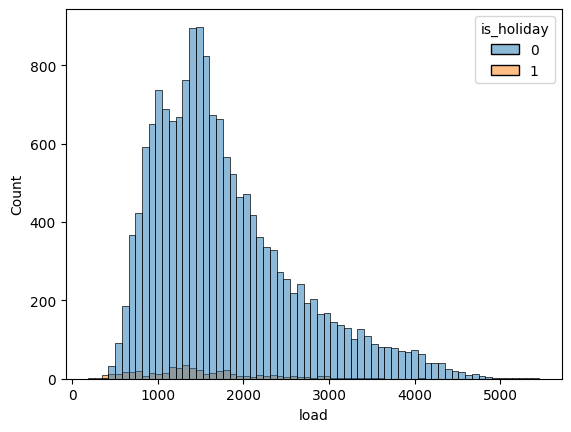

In [ ]:
# распределение целевой переменной имеет существенную несимметрию
# (скошено вправо)
sns.histplot(x='load', data=df_train, hue='is_holiday');

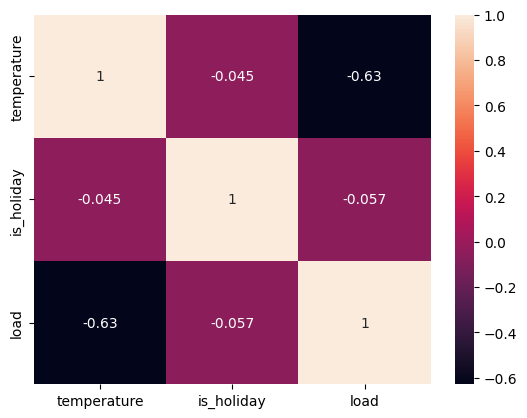

In [ ]:
# имеется существенная корреляция между температурой и нагрузкой, что логично
sns.heatmap(df_train[['temperature', 'is_holiday', 'load']].corr(), annot=True);

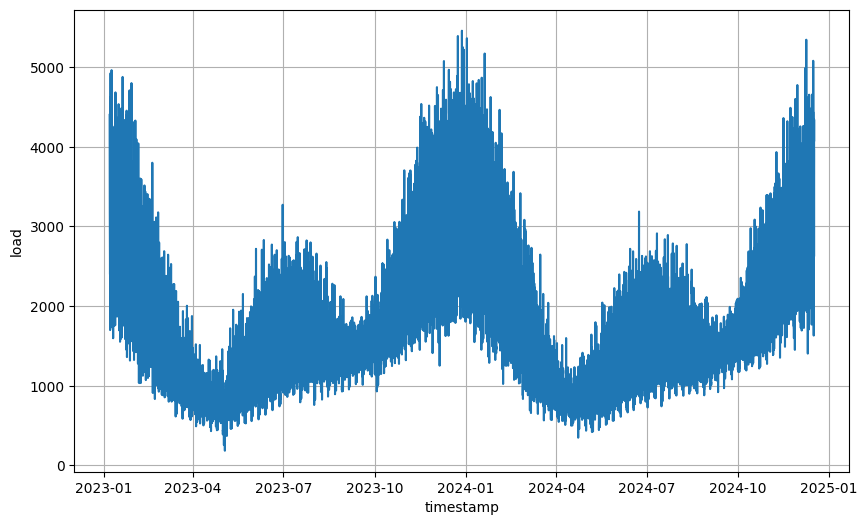

In [ ]:
# нагрузка в зависимости от даты выглядит как периодическая функция
plt.figure(figsize=(10, 6), dpi=100)
sns.lineplot(x='timestamp', y='load', data=df_train);

plt.grid()

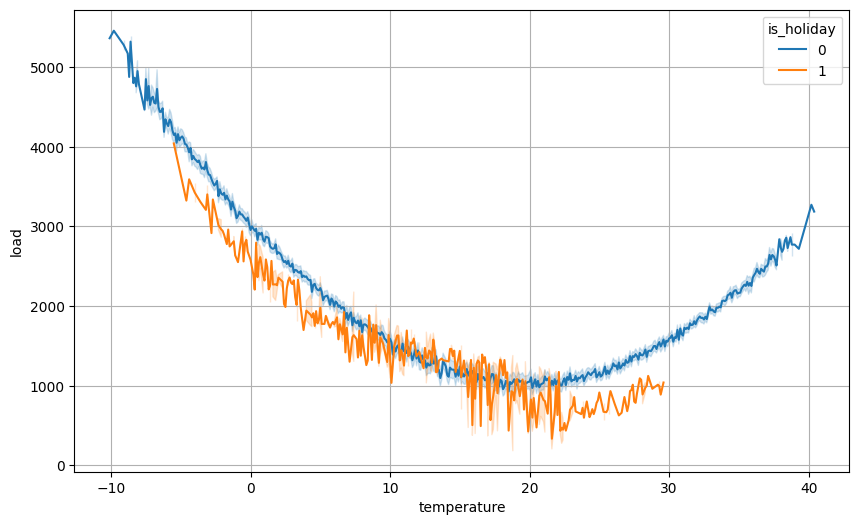

In [ ]:
# максимальное потребление э/э при наименьшей температуры (из-за применения
# обогревателей, короткого светового дня); с увеличением температуры
# потребление э/э сначала падает, а потом растет, зависимость напоминает
# параболу; в праздничные дни потребление снижается
plt.figure(figsize=(10, 6), dpi=100)
sns.lineplot(x='temperature', y='load', data=df_train, hue='is_holiday');

plt.grid()

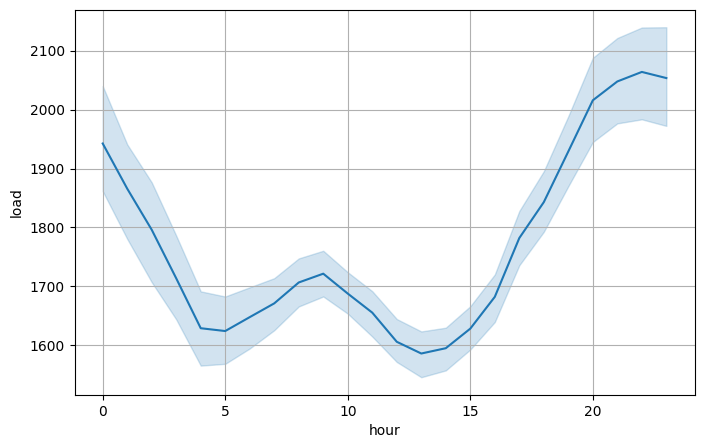

In [ ]:
# потребление э/э в течение суток выглядит как классический график нагрузки,
# видны утренний и вечерний максимумы
plt.figure(figsize=(8, 5), dpi=100)
sns.lineplot(x='hour', y='load', data=df_train);

plt.grid()

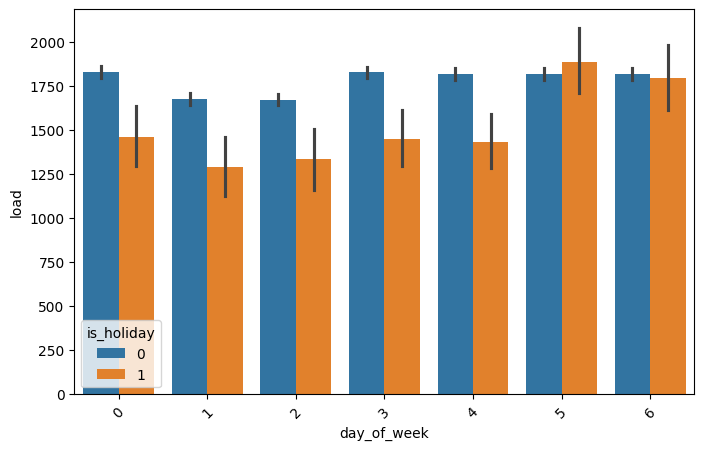

In [ ]:
# среднее потребление электроэнергии для всех дней недели отличается мало,
# как и СКО (если не учитывать праздничные дни)
plt.figure(figsize=(8, 5), dpi=100)
sns.barplot(x='day_of_week', y='load', data=df_train,
            estimator='mean', hue='is_holiday');

plt.xticks(rotation=45);

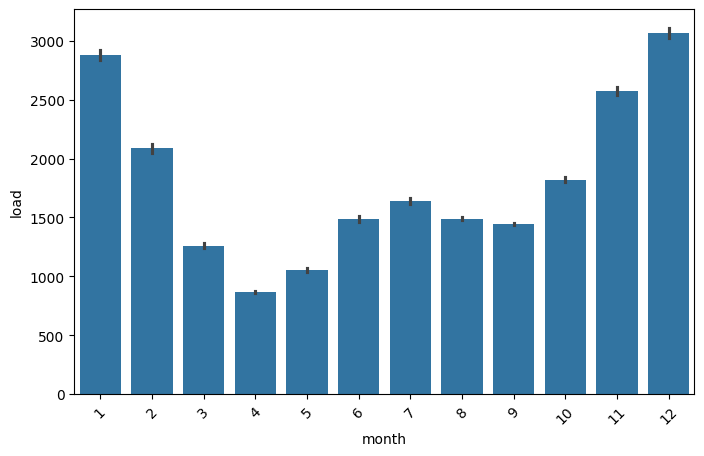

In [ ]:
# наибольшее потребление э/э в зимние месяцы, что логично
plt.figure(figsize=(8, 5), dpi=100)
sns.barplot(x='month', y='load', data=df_train, estimator='mean');

plt.xticks(rotation=45);

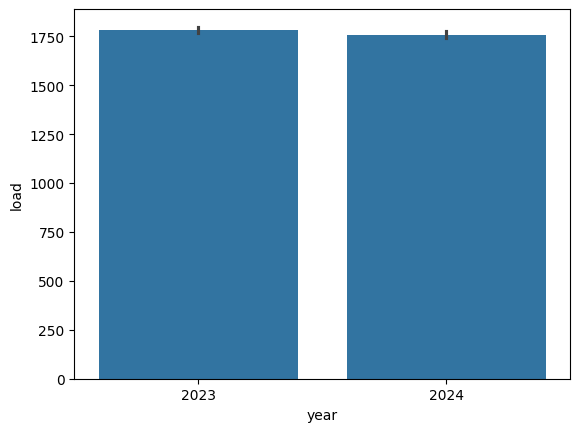

In [ ]:
# потребление год к году практически не меняется
sns.barplot(x='year', y='load', data=df_train, estimator='mean');

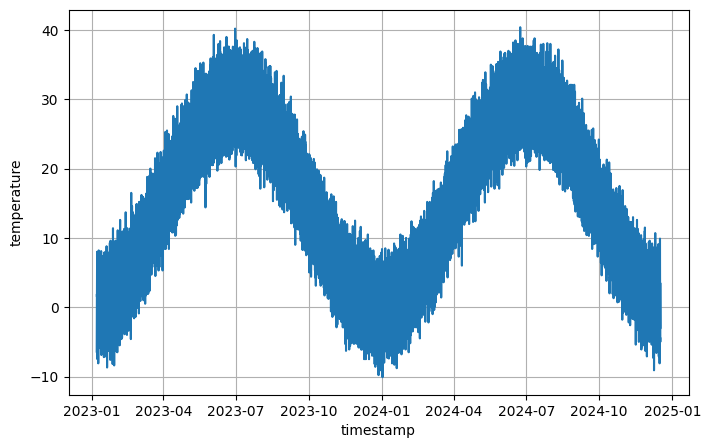

In [ ]:
# видим ожидаемый график зависимости температуры от даты
plt.figure(figsize=(8, 5), dpi=100)
sns.lineplot(x='timestamp', y='temperature', data=df_train);

plt.grid()

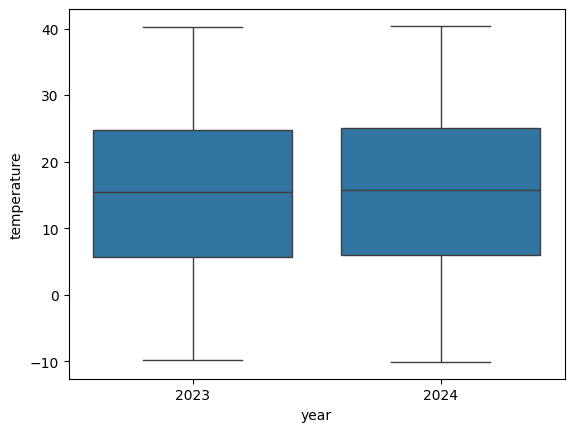

In [ ]:
# температура год к году практически не меняется
sns.boxplot(x='year', y='temperature', data=df_train);

**Анализ временного ряда**

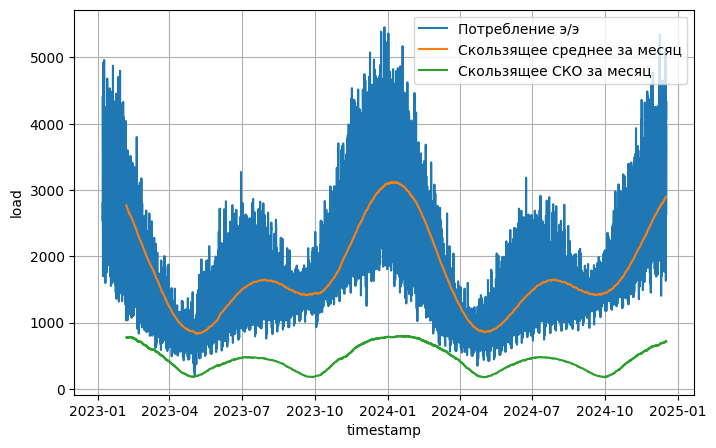

In [ ]:
plt.figure(figsize=(8, 5), dpi=100)
sns.lineplot(x='timestamp', y='load', data=df_train, label='Потребление э/э');
# добавим скользящее среднее за месяц (около 720 часов)
sns.lineplot(x=df_train['timestamp'],
             y=df_train['load'].rolling(window=720).mean(),
             label='Скользящее среднее за месяц');
# добавим скользящее СКО за месяц
sns.lineplot(x=df_train['timestamp'],
             y=df_train['load'].rolling(window=720).std(),
             label='Скользящее СКО за месяц');

plt.grid()

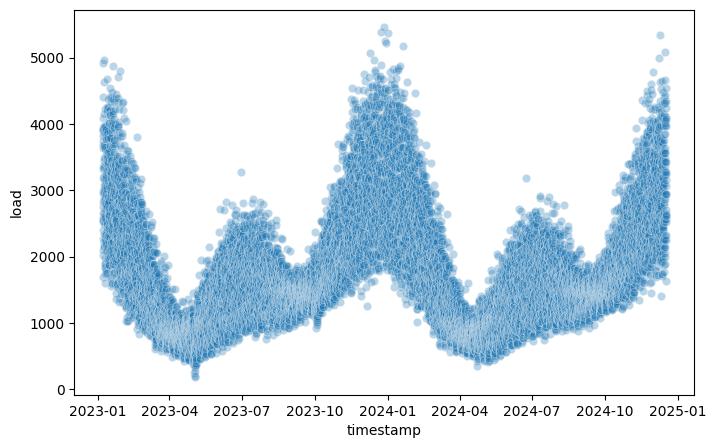

In [ ]:
# посмотрим то же самое на scatterplot
plt.figure(figsize=(8, 5), dpi=100)
sns.scatterplot(x='timestamp', y='load', data=df_train, alpha=0.3);

Разложим временной ряд на компоненты (time series decomposition) - тренд, сезонность и случайные колебания. Воспользуемся для этого фунцией seasonal_decompose() из библиотеки statsmodels. Создадим вспомогательные датафреймы с разной временной периодичностью, чтобы передавать их в seasonal_decompose(), воспользуемся для этого pd.resample() - обобщим данные:

In [ ]:
df_hour = df_train[['timestamp', 'load']].set_index('timestamp', drop=True)
df_day = df_hour.resample(rule='d').sum()

df_day.head()

,load
timestamp,
2023-01-07,74773.1
2023-01-08,77419.5
2023-01-09,72750.5
2023-01-10,67297.8
2023-01-11,70614.1


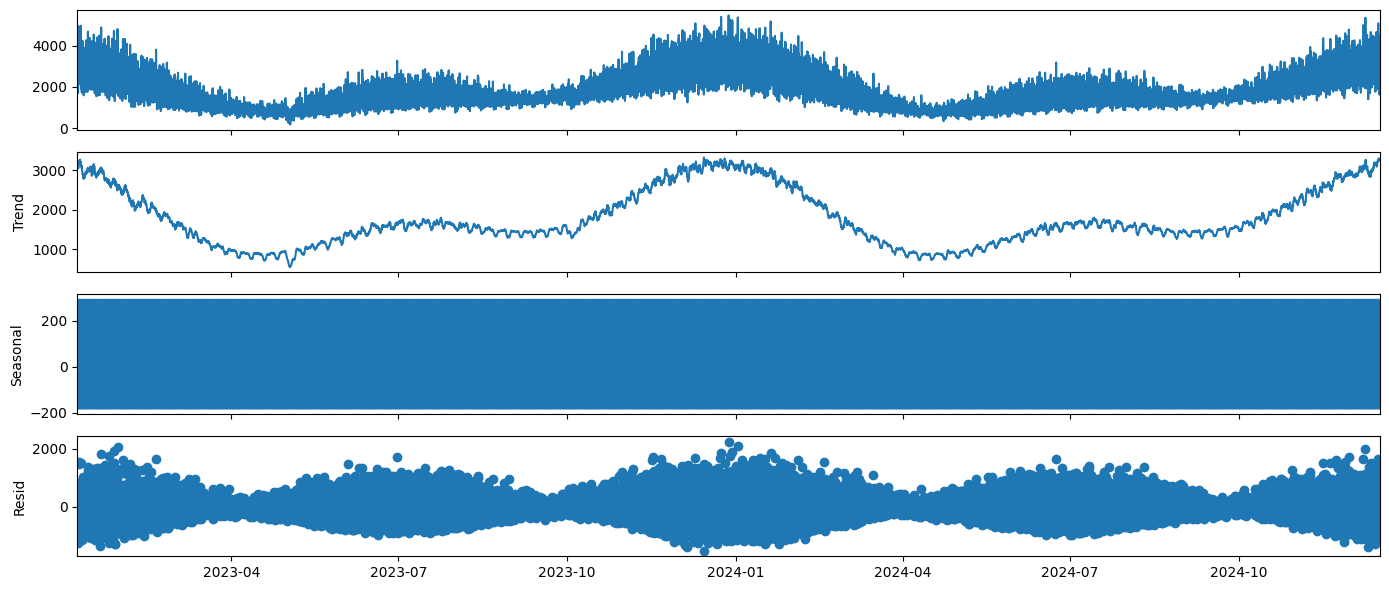

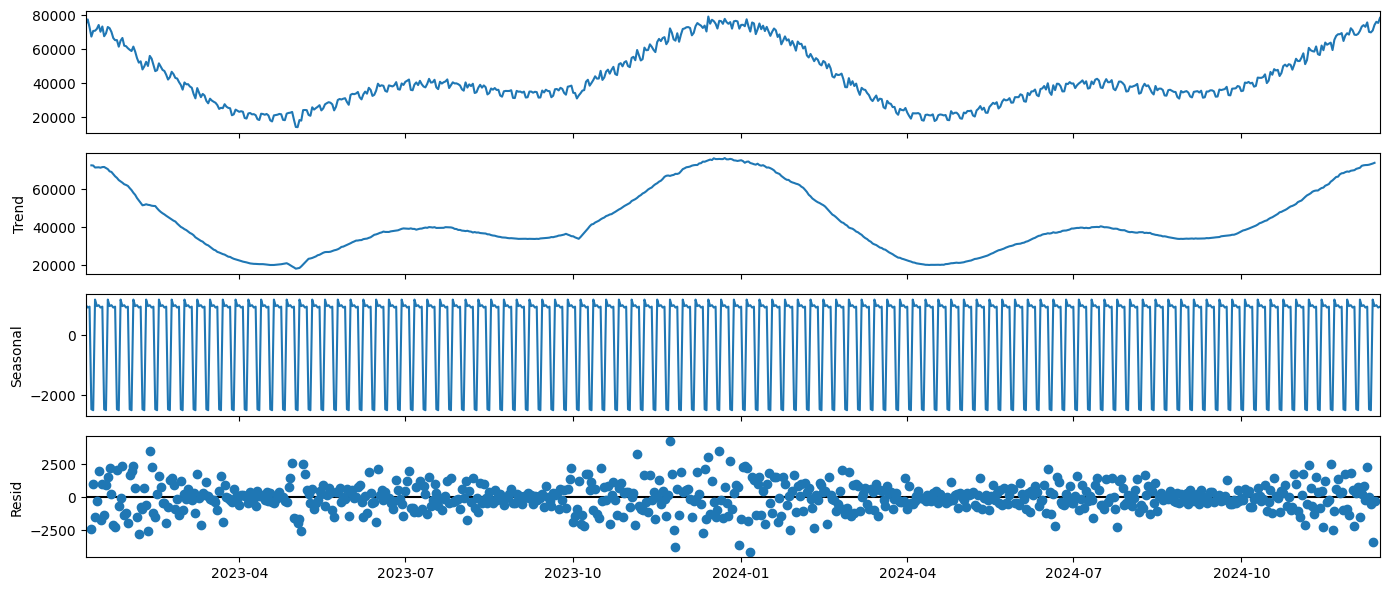

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# задаем размер графика
from pylab import rcParams
rcParams['figure.figsize'] = 14, 6

# для часовых интервалов
decompose_hour = seasonal_decompose(df_hour)
decompose_hour.plot()

# для дневных интервалов
decompose_day = seasonal_decompose(df_day)
decompose_day.plot()

plt.show()

Визуально тренд (постоянный, на всем имеющемся интервале) отсутствует. При этом среднее значение и дисперсия со временем меняются существенно, т.е. ряд может быть нестационарным.

Для оценки стационарности временного ряда применим тест Дики-Фуллера (Dickey-Fuller test).

В данном случае гипотезы следующие:

* нулевая гипотеза предполагает, что процесс нестационарный;
* альтернативная гипотеза говорит об обратном.

Примем уровень значимости α = 0,05.

Проведем тест для датафрейма df_day, который содержит обобщенные данные за каждый день, а не за каждый час:

In [ ]:
from statsmodels.tsa.stattools import adfuller

# adf_test возвращает кортеж из нескольких значений
adf_test = adfuller(df_day, autolag='AIC')

# выведем результаты в виде датафрейма
output = pd.Series(adf_test[0:4], index=['Test Statistics', 'p-value',
                                        'No. of lags used',
                                        'Number of observations used'],
                   name='Dickey-Fuller test results')

for key, values in adf_test[4].items():
  output['critical value (%s)' %key] = values

output

,Dickey-Fuller test results
Test Statistics,-3.201776
p-value,0.019882
No. of lags used,20.000000
Number of observations used,689.000000
critical value (1%),-3.439877
critical value (5%),-2.865744
critical value (10%),-2.569009


Согласно полученному p-value, временной ряд является стационарным, однако мы видим, что он не соответствует требованиям стационарности, поскольку присутствует сезонность.

Сделаем то же самое для датафрейма df_hour с почасовыми данными:

In [ ]:
adf_test = adfuller(df_hour, autolag='AIC')

output = pd.Series(adf_test[0:4], index=['Test Statistics', 'p-value',
                                        'No. of lags used',
                                        'Number of observations used'],
                   name='Dickey-Fuller test results')

for key, values in adf_test[4].items():
  output['critical value (%s)' %key] = values

output

,Dickey-Fuller test results
Test Statistics,-1.971710
p-value,0.299113
No. of lags used,44.000000
Number of observations used,16995.000000
critical value (1%),-3.430735
critical value (5%),-2.861710
critical value (10%),-2.566861


Поскольку p-value > 0.05, мы не можем отклонить нулевую гипотезу - часовой временной ряд не стационарен.

Для получения стационарного ряда необходимо исключить из него тренд и сезонность.

Начнем с логарифмирования ряда, чтобы уменьшить значения и ослабить восходящий тренд. После этого найдем скользящее среднее за сутки.

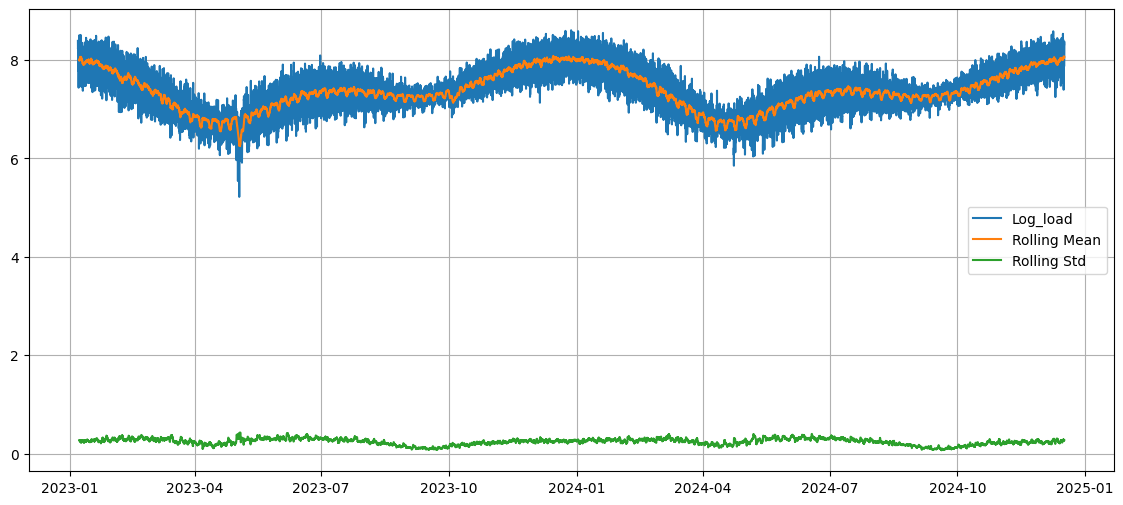

In [ ]:
df_log = np.log(df_hour)
# скользящее среднее за день (24 часа)
moving_avg = df_log.rolling(window=24).mean()
# СКО за день
std = df_log.rolling(window=24).std()

plt.plot(df_log, label='Log_load')
plt.plot(moving_avg, label='Rolling Mean')
plt.plot(std, label='Rolling Std')

plt.legend(loc='best')
plt.grid()

Теперь рассчитаем разницу между текущим значением ряда и средним значением для каждой временной метки - таким образом мы исключаем тренды и получаем более стационарный ряд.

In [ ]:
df_log_moving_avg_diff = df_log - moving_avg
# из-за расчета скользящего среднего появляются значения NaN, удалим их
df_log_moving_avg_diff = df_log_moving_avg_diff.dropna()

df_log_moving_avg_diff.head()

,load
timestamp,
2023-01-07 23:00:00,0.492198
2023-01-08 00:00:00,0.266885
2023-01-08 01:00:00,-0.071175
2023-01-08 02:00:00,0.280826
2023-01-08 03:00:00,0.132060


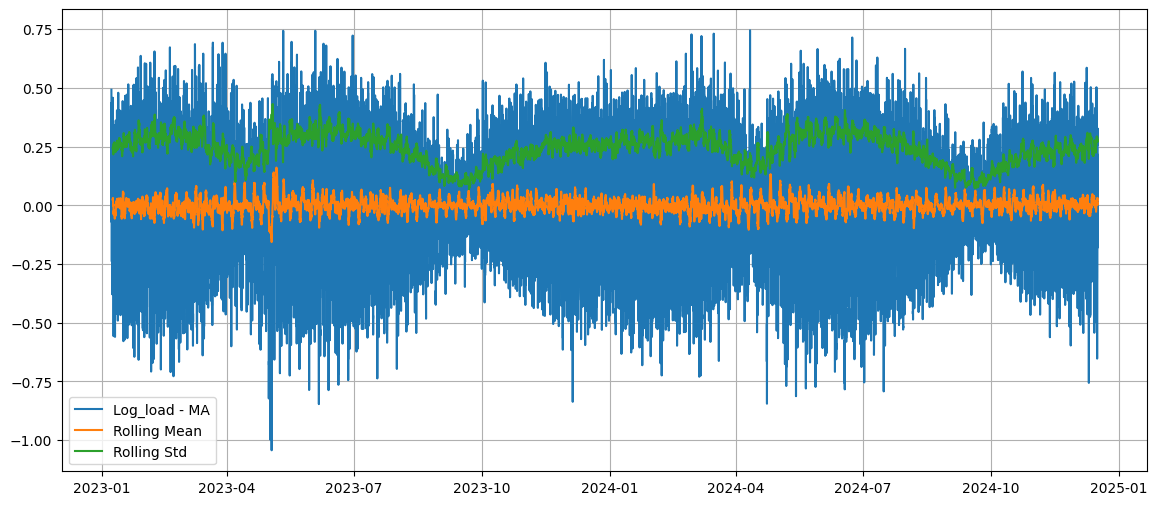

In [ ]:
# посмотрим на график для df_log_moving_avg_diff
moving_avg = df_log_moving_avg_diff.rolling(window=24).mean()
std = df_log_moving_avg_diff.rolling(window=24).std()

plt.plot(df_log_moving_avg_diff, label='Log_load - MA')
plt.plot(moving_avg, label='Rolling Mean')
plt.plot(std, label='Rolling Std')

plt.legend(loc='best')
plt.grid()

Снова проведем тест Дики-Фуллера:

In [ ]:
adf_test = adfuller(df_log_moving_avg_diff, autolag='AIC')

output = pd.Series(adf_test[0:4], index=['Test Statistics', 'p-value',
                                        'No. of lags used',
                                        'Number of observations used'],
                   name='Dickey-Fuller test results')

for key, values in adf_test[4].items():
  output['critical value (%s)' %key] = values

output

,Dickey-Fuller test results
Test Statistics,-23.565595
p-value,0.000000
No. of lags used,44.000000
Number of observations used,16972.000000
critical value (1%),-3.430735
critical value (5%),-2.861710
critical value (10%),-2.566861


После выполненных преобразований p-value снизилось до 0 - такой ряд можно считать стационарным.

В некоторых случаях в данных может наблюдаться высокая сезонность. В таких случаях простое удаление тренда мало чем поможет. Необходимо также учитывать сезонность в ряду. Одним из методов решения этой задачи является дифференцирование.

Дифференцирование выполняется путем вычитания предыдущего наблюдения из текущего наблюдения.

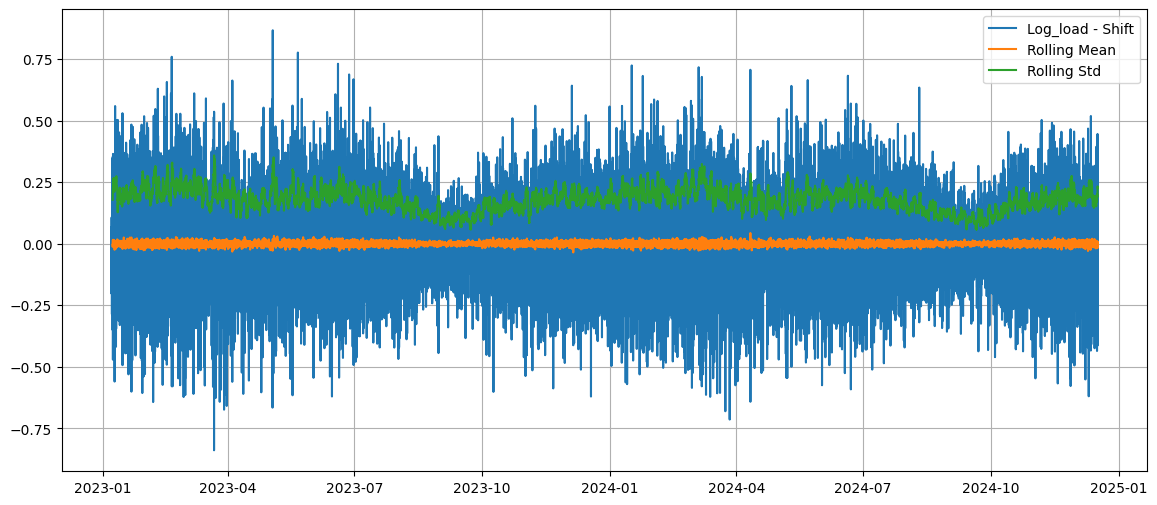

In [ ]:
df_log_diff = df_log - df_log.shift(periods=1)
# из-за сдвига появляются значения NaN, удалим их
df_log_diff = df_log_diff.dropna()

moving_avg = df_log_diff.rolling(window=24).mean()
std = df_log_diff.rolling(window=24).std()

plt.plot(df_log_diff, label='Log_load - Shift')
plt.plot(moving_avg, label='Rolling Mean')
plt.plot(std, label='Rolling Std')

plt.legend(loc='best')
plt.grid()

После такого преобразования мы видим на графике практически постоянные значения среднего и стандартного отклонения - т.е. мы получили стационарный ряд.

Еще раз проведем тест Дики-Фуллера:

In [ ]:
adf_test = adfuller(df_log_diff, autolag='AIC')

output = pd.Series(adf_test[0:4], index=['Test Statistics', 'p-value',
                                        'No. of lags used',
                                        'Number of observations used'],
                   name='Dickey-Fuller test results')

for key, values in adf_test[4].items():
  output['critical value (%s)' %key] = values

output

,Dickey-Fuller test results
Test Statistics,-25.834294
p-value,0.000000
No. of lags used,44.000000
Number of observations used,16994.000000
critical value (1%),-3.430735
critical value (5%),-2.861710
critical value (10%),-2.566861


Для такого ряда p-value также равно 0.

Для предварительного выбора параметров моделей типа ARIMA(p, d, q) построим графики  автокорреляционной (autocorrelation function - ACF) и частичной автокорреляционной (partial autocorrelation function - PACF) функций. Также добавим на графики 95% доверительные интервалы.

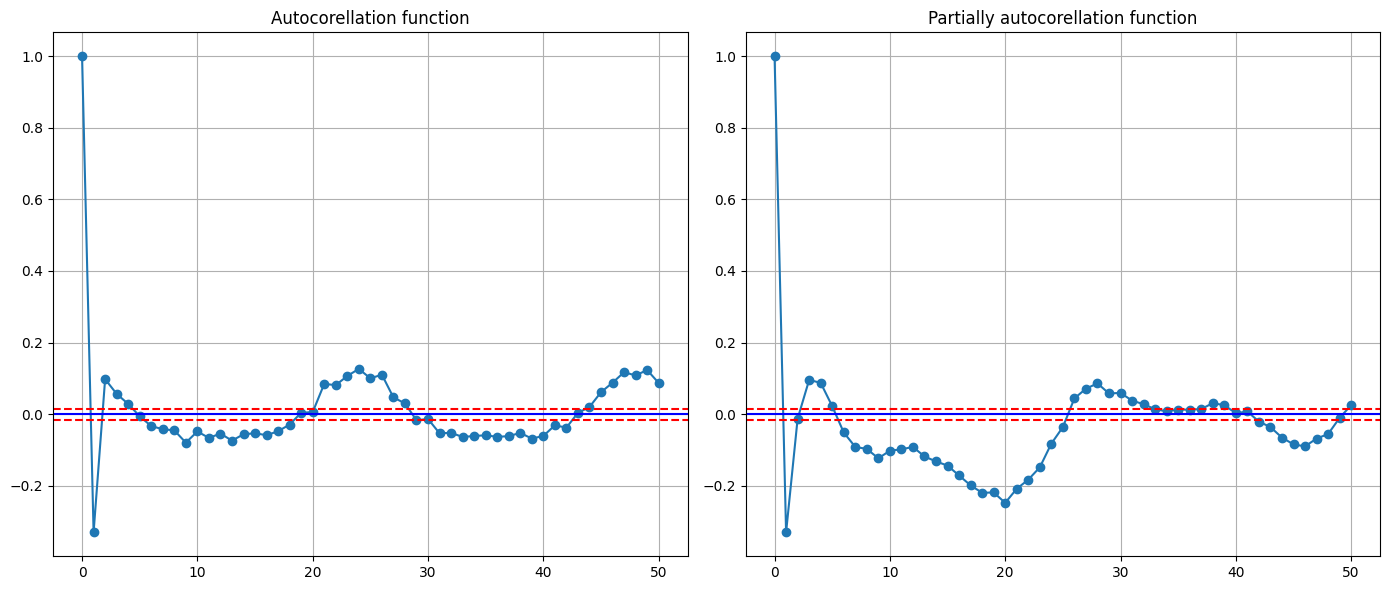

In [ ]:
from statsmodels.tsa.stattools import acf, pacf

acf = acf(df_log_diff, nlags=50)
pacf = pacf(df_log_diff, nlags=50, method='ols')

plt.subplot(121)
plt.plot(acf, marker='o')
plt.axhline(y=0, linestyle='-', color='blue')
# доверительный интервал 95% (рассчитываются как ±1.96/√n, что соответствует
# 95% уровню доверия при предположении о нормальном распределении)
plt.axhline(y=-1.96 / np.sqrt(len(df_log_diff)), linestyle='--', color='red')
plt.axhline(y=1.96 / np.sqrt(len(df_log_diff)), linestyle='--', color='red')
plt.title('Autocorellation function')
plt.grid()

plt.subplot(122)
plt.plot(pacf, marker='o')
plt.axhline(y=0, linestyle='-', color='blue')
# доверительный интервал 95% (рассчитываются как ±1.96/√n, что соответствует
# 95% уровню доверия при предположении о нормальном распределении)
plt.axhline(y=-1.96 / np.sqrt(len(df_log_diff)), linestyle='--', color='red')
plt.axhline(y=1.96 / np.sqrt(len(df_log_diff)), linestyle='--', color='red')
plt.title('Partially autocorellation function')
plt.grid()

plt.tight_layout()

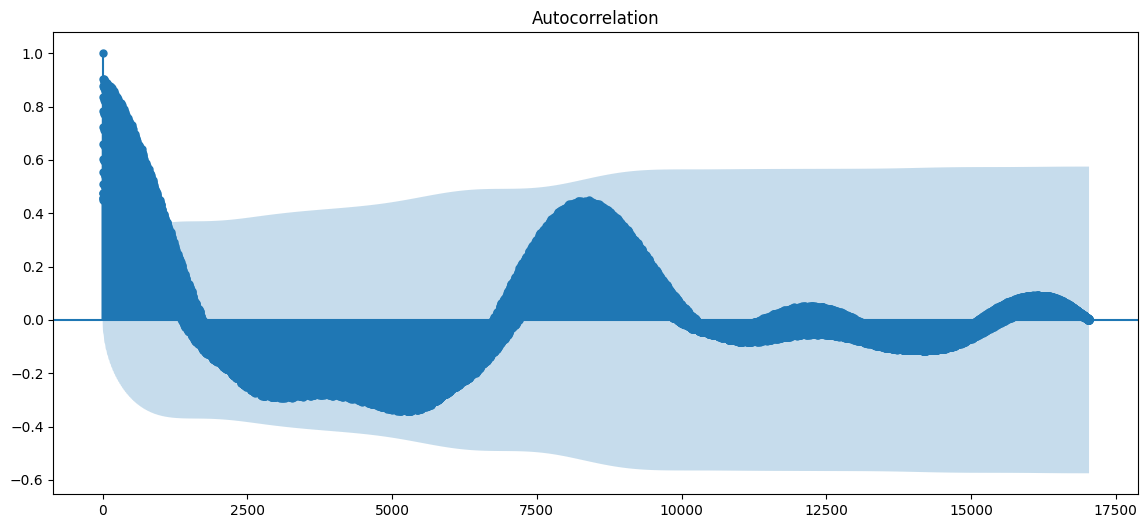

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

# lags - массив значений лагов, откладываемых по горизонтальной оси
plot_acf(df_hour, lags=np.arange(len(df_hour)));
# добавим отступы сверху и снизу на графике
plt.axis('tight');

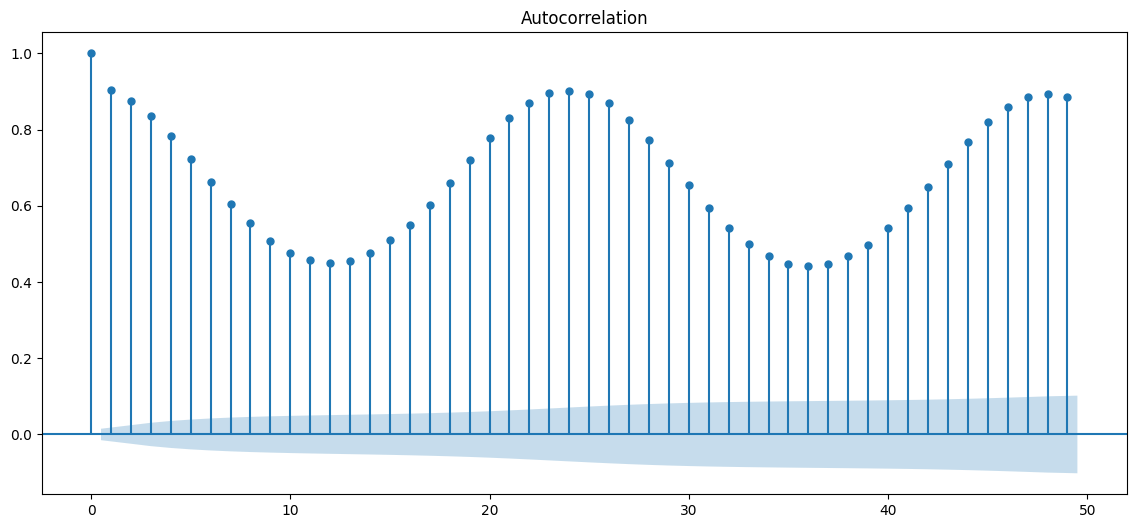

In [ ]:
# также построим график для меньшего числа lags
plot_acf(df_hour, lags=range(50));
plt.axis('tight');

Из первого графика видно, что с исходным рядом сильнее коррелируют лаги 8000-9000, что соответствует интервалу примерно в год (т.к. в году 8760 часов) - это абсолютно логично. Т.е. можно предположить наличие ежегодных сезонных колебаний. Поскольку корреляция не всегда положительна (она определяется временем года), можно сказать, что тренда в данных нет.

Из второго графика видно, что с исходным рядом наибольшую корреляцию имеют лаги, кратные 24 (сутки), что также логично. Т.е. можно предположить наличие суточных колебаний.

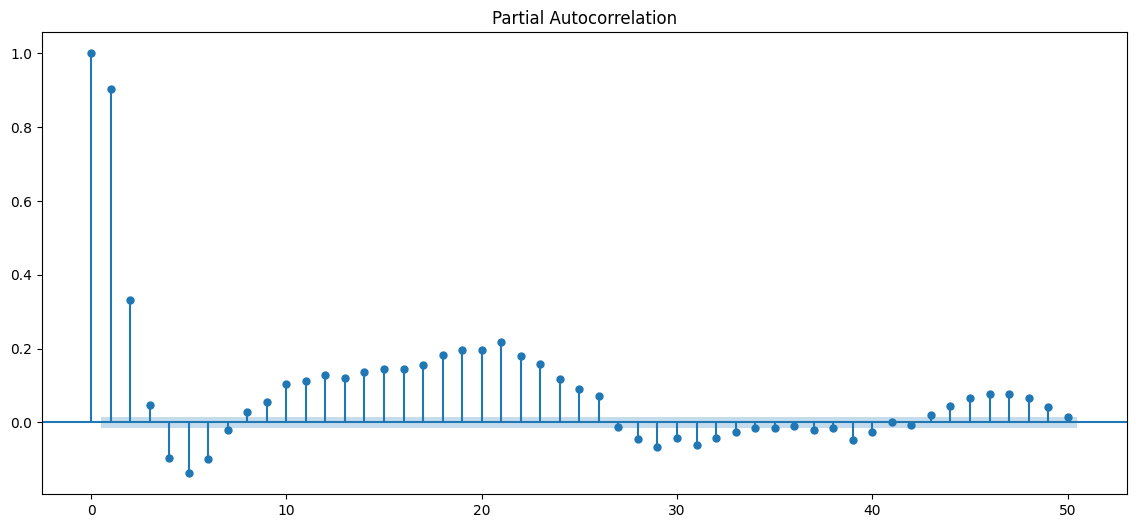

In [ ]:
# построим график частичной автокорреляционной функции (PACF)
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df_hour, lags=50);
plt.axis('tight');

**Выводы**

*   Имеется существенная корреляция между температурой и нагрузкой, максимальное потребление достигается при наименьшей температуре (из-за применения обогревателей, короткого светового дня); с увеличением температуры потребление э/э сначала падает, а потом растет (что объясняется использованием кондиционеров и пр.), зависимость напоминает параболу. Поэтому есть смысл попробовать добавить новый признак - квадрат температуры.
*   В праздничные дни потребление э/э снижается.
*   Потребление э/э в течение суток выглядит как классический график нагрузки (видны утренний и вечерний максимумы).
*  Часовые данные потребления электроэнергии являются нестационарными, что видно визуально и проверено тестом Дики-Фуллера. Но с помощью математических преобразований этой временной ряд возможно привести к стационарному.
*  График автокорреляционной функции показывает, что с исходным рядом имеют наибольшую корреляцию данные с лагом около 8000-9000 (что соответствует интервалу в год) и с лагами, кратными 24 (что соответствует интервалу в сутки).

# 3. Обработка данных

In [ ]:
# разделим данные на признаки и таргет
X_train = df_train.drop(columns='load')
y_train = df_train['load']

X_test = df_test.drop(columns='load')
y_test = df_test['load']

**3.1 Обработка пропусков**

Пропусков в данном датасете нет.

**3.2 Работа с выбросами**

Оценим количество выбросов в датасете через межквартильный интервал (IQR):

In [ ]:
def outlier_count(X):
  """Функция для определения процента выбросов для числовых признаков"""
  Q25, Q75 = X.quantile(0.25, axis=0), X.quantile(0.75, axis=0)
  IQR = Q75 - Q25
  lower_bound, upper_bound = Q25 - 1.5 * IQR, Q75 + 1.5 * IQR

  # доля выбросов для каждого признака в процентах
  quantity = ((X >= upper_bound) | (X <= lower_bound)).sum(axis=0) / \
               X.shape[0] * 100
  return quantity.sort_values(ascending=False)


outlier_count(df_train[['temperature', 'load']])
# выбросов не так много

,0
load,3.480047
temperature,0.000000


**3.3 Создание новых признаков**

Создадим новый признак temperature_square как квадрат температуры:

In [ ]:
X_train['temperature_square'] = X_train['temperature'] ** 2
X_test['temperature_square'] = X_test['temperature'] ** 2

**3.4 Кодирование категориальных переменных**

Алгоритмы градиентного бустинга, построенные на основе решающих деревьев (XGBoost, LightGBM, CatBoost), поддерживают обработку категориальных данных. При этом признаки, сформированные на основе даты (hour, day_of_week и т.д.), являются числовыми. В целом, можно применить разные подходы для данных признаков, и хороший результат получается при OneHot-кодировании (это уместно, когда категорий не очень много).

Применим OneHotEncoder, в котором можно указать параметр handle_unknown='ignore'. В этом случае при обнаружении неизвестной категории во время преобразования столбец будет содержать все нули. Также через drop='first' удаляем первый (избыточный) признак.

In [ ]:
# выберем категориальные признаки
cat_features = ['is_holiday', 'hour', 'day_of_week', 'day_of_month', 'month',
                'quarter', 'year']

In [ ]:
from sklearn.preprocessing import OneHotEncoder

onehotencoder = OneHotEncoder(drop='first', sparse_output=False,
                              handle_unknown='ignore')
encoded_X_train = pd.DataFrame(onehotencoder.fit_transform(
                               X_train[cat_features]))
# добавляем названия столбцов
encoded_X_train.columns = onehotencoder.get_feature_names_out()

# присоединим закодированные признаки к датафрейму и удалим исходные
X_train = X_train.join(encoded_X_train).drop(columns=cat_features)

In [ ]:
# то же самое для test
# используем тот же encoder, обученный на train
encoded_X_test = pd.DataFrame(onehotencoder.transform(X_test[cat_features]))
encoded_X_test.columns = onehotencoder.get_feature_names_out()

X_test = X_test.join(encoded_X_test).drop(columns=cat_features)

**3.5 Масштабирование числовых признаков**

Применим StandardScaler:

In [ ]:
from sklearn.preprocessing import StandardScaler

# выберем числовые признаки
num_features = ['temperature', 'temperature_square']
scaler = StandardScaler()

X_train_scaled = X_train.drop(columns=num_features).join(
                 pd.DataFrame(scaler.fit_transform(X_train[num_features]),
                                                    columns=num_features))
X_test_scaled = X_test.drop(columns=num_features).join(
                 pd.DataFrame(scaler.transform(X_test[num_features]),
                                                    columns=num_features))

In [ ]:
# проверим получившиеся средние значения и СКО
X_train_scaled[num_features].mean(), X_train_scaled[num_features].std()

(temperature           9.340468e-17
 temperature_square    4.003058e-17
 dtype: float64,
 temperature           1.000029
 temperature_square    1.000029
 dtype: float64)

In [ ]:
# в данном случае для test средние значения и СКО существенно отличаются от 0 и
# 1, т.к. scaler обучен на train, а там выборка намного больше
X_test_scaled[num_features].mean(), X_test_scaled[num_features].std()

(temperature          -1.380984
 temperature_square   -0.956498
 dtype: float64,
 temperature           0.380900
 temperature_square    0.053555
 dtype: float64)

In [ ]:
# финальная проверка на корректность данных
X_train_scaled.info()
print('-' * 100)
X_test_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17040 entries, 0 to 17039
Data columns (total 78 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   timestamp           17040 non-null  datetime64[ns]
 1   is_holiday_1        17040 non-null  float64       
 2   hour_1              17040 non-null  float64       
 3   hour_2              17040 non-null  float64       
 4   hour_3              17040 non-null  float64       
 5   hour_4              17040 non-null  float64       
 6   hour_5              17040 non-null  float64       
 7   hour_6              17040 non-null  float64       
 8   hour_7              17040 non-null  float64       
 9   hour_8              17040 non-null  float64       
 10  hour_9              17040 non-null  float64       
 11  hour_10             17040 non-null  float64       
 12  hour_11             17040 non-null  float64       
 13  hour_12             17040 non-null  float64   

In [ ]:
X_train_scaled.isnull().sum().sum(), X_test_scaled.isnull().sum().sum()

(np.int64(0), np.int64(0))

# 4. Моделирование и оценка результата

**4.1 Prophet**

В качестве базовой модели применим Prophet, т.к. он требует минимального количества настроек.

Входные данные для Prophet всегда представляют собой датафрейм с двумя столбцами: ds и y. Столбец ds (datestamp) должен иметь формат, ожидаемый Pandas, в идеале — ГГГГ-ММ-ДД для даты или ГГГГ-ММ-ДД ЧЧ:ММ:СС для временной метки. Столбец y должен быть числовым и представлять собой целевую переменную.

Также возможно передать в Prophet праздничные дни, для этого создается датафрейм playoffs, который состоит из двух столбцов (holiday и ds) и одной строки для каждого события.

In [ ]:
# создадим вспомогательный датафрейм holidays для передачи в Prophet
# необходимо добавить туда все праздничные дни, попадающие в даты train и test
# при этом убираем временную метку (оставляем только дату) и оставляем только
# уникальные дни без повторений
holidays = pd.concat([df_train, df_test], axis=0)
holidays = holidays[holidays['is_holiday'] == 1]['timestamp'].dt.date. \
           drop_duplicates()

holidays

,timestamp
672,2023-02-04
696,2023-02-05
720,2023-02-06
744,2023-02-07
768,2023-02-08
792,2023-02-09
816,2023-02-10
2736,2023-05-01
2760,2023-05-02
2784,2023-05-03


In [ ]:
from prophet import Prophet

# оставим только необходимые столбцы, также переименуем их
df_train_prophet = df_train[['timestamp', 'load']].rename(
                   columns={'timestamp': 'ds', 'load': 'y'})
X_test_prophet = df_test[['timestamp']].rename(columns={'timestamp': 'ds'})

# передадим в модель праздничные дни
playoffs = pd.DataFrame({'holiday': 'playoff', 'ds': holidays,
                         'lower_window': 0, 'upper_window': 0})

model = Prophet(holidays=playoffs)
model.fit(df_train_prophet)

# forecast - это датафрейм с результатами
forecast = model.predict(X_test_prophet)

forecast

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,playoff,playoff_lower,playoff_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-12-17 00:00:00,2785.368003,2393.378066,3587.915387,2785.368003,2785.368003,167.782354,167.782354,167.782354,191.726027,...,0.0,0.0,0.0,-23.943673,-23.943673,-23.943673,0.0,0.0,0.0,2953.150357
1,2024-12-17 01:00:00,2785.829288,2251.271561,3415.195934,2785.829288,2785.829288,73.199717,73.199717,73.199717,103.571533,...,0.0,0.0,0.0,-30.371816,-30.371816,-30.371816,0.0,0.0,0.0,2859.029006
2,2024-12-17 02:00:00,2786.290574,2161.637144,3349.606671,2786.290574,2786.290574,-25.186456,-25.186456,-25.186456,11.736909,...,0.0,0.0,0.0,-36.923365,-36.923365,-36.923365,0.0,0.0,0.0,2761.104117
3,2024-12-17 03:00:00,2786.751859,2099.354159,3203.659181,2786.751859,2786.751859,-112.215042,-112.215042,-112.215042,-68.652681,...,0.0,0.0,0.0,-43.562361,-43.562361,-43.562361,0.0,0.0,0.0,2674.536817
4,2024-12-17 04:00:00,2787.213145,2003.384683,3224.109538,2787.213145,2787.213145,-174.350848,-174.350848,-174.350848,-124.099800,...,0.0,0.0,0.0,-50.251047,-50.251047,-50.251047,0.0,0.0,0.0,2612.862297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,2024-12-19 19:00:00,2816.274130,2416.489128,3631.504277,2816.274130,2816.274130,214.701190,214.701190,214.701190,163.496787,...,0.0,0.0,0.0,51.204403,51.204403,51.204403,0.0,0.0,0.0,3030.975321
68,2024-12-19 20:00:00,2816.735416,2539.032825,3663.082125,2816.735416,2816.735416,289.988367,289.988367,289.988367,238.271497,...,0.0,0.0,0.0,51.716870,51.716870,51.716870,0.0,0.0,0.0,3106.723783
69,2024-12-19 21:00:00,2817.196701,2586.068472,3762.896724,2817.196701,2817.196701,338.116564,338.116564,338.116564,286.112481,...,0.0,0.0,0.0,52.004083,52.004083,52.004083,0.0,0.0,0.0,3155.313265
70,2024-12-19 22:00:00,2817.657987,2560.465260,3762.728681,2817.657987,2817.657987,346.405195,346.405195,346.405195,294.318303,...,0.0,0.0,0.0,52.086893,52.086893,52.086893,0.0,0.0,0.0,3164.063182


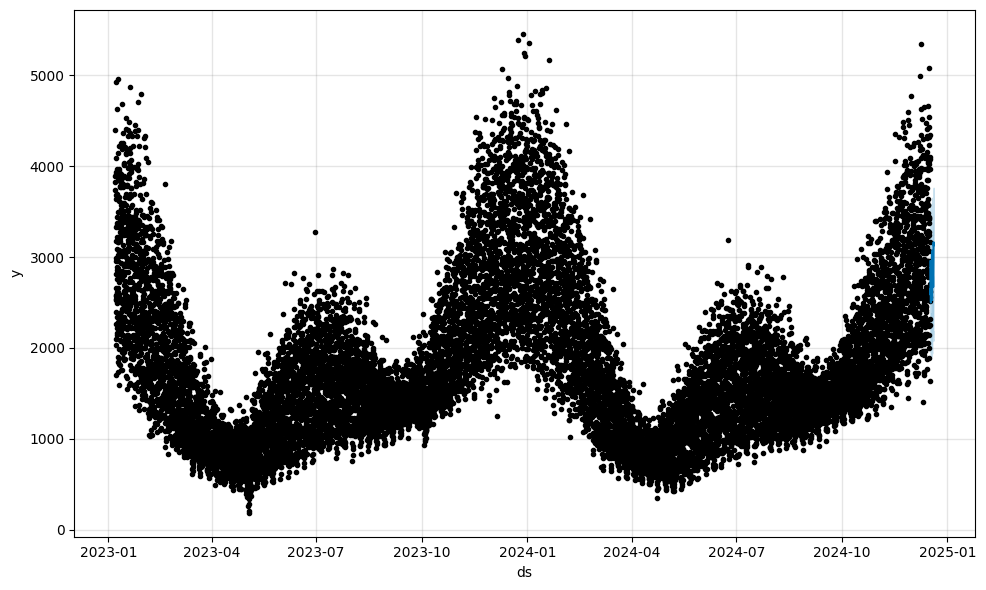

In [ ]:
fig1 = model.plot(forecast)

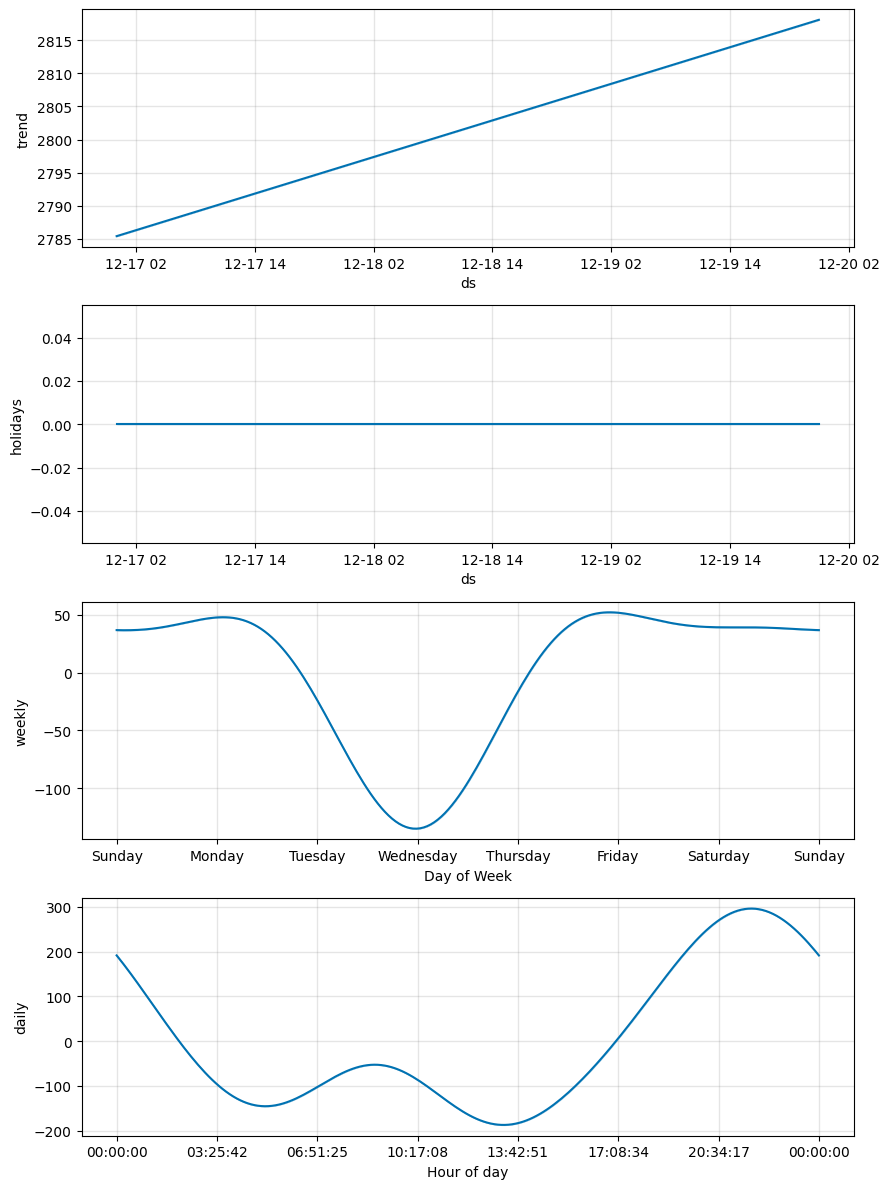

In [ ]:
fig2 = model.plot_components(forecast)

In [ ]:
# оценим MAPE
from sklearn.metrics import mean_absolute_percentage_error

# в качестве предсказанных значений берем столбец 'yhat' из forecast
# нужно умножать на 100, т.к. MAPE из sklearn возвращает относительное значение
# в диапазоне [0; 1]
mape_prophet = round((mean_absolute_percentage_error(y_test, forecast['yhat'])
             * 100), 3)

mape_prophet
# 19.469% с учетом праздничных дней playoffs

19.469

Создадим датафрейм scores, где будут храниться результаты всех моделей:

In [ ]:
scores = pd.DataFrame(columns=['MAPE, %'], index=['Prophet', 'ARIMA', 'XGBoost',
                                                  'LightGBM', 'CatBoost'])
scores.loc['Prophet'] = mape_prophet

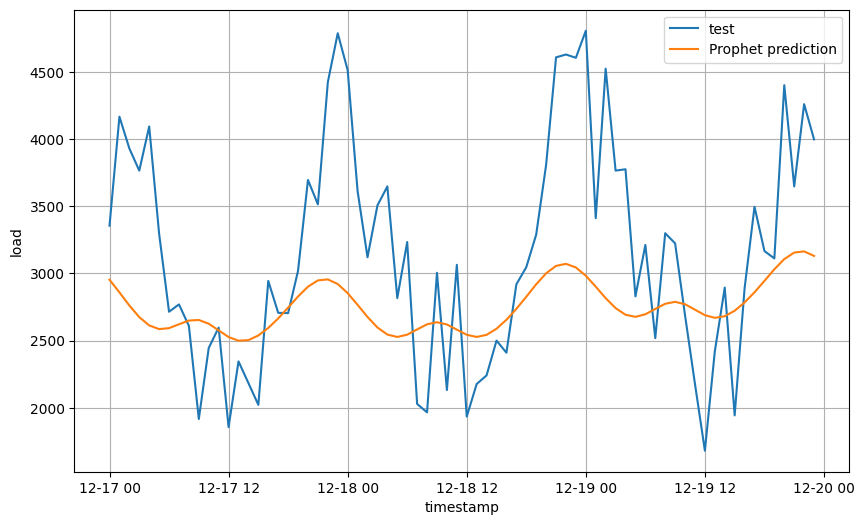

In [ ]:
# покажем на одном графике реальные значения и предсказанные
plt.figure(figsize=(10, 6), dpi=100)
sns.lineplot(x='timestamp', y='load', data=df_test, label='test');
sns.lineplot(x='ds', y='yhat', data=forecast, label='Prophet prediction');

plt.grid()

Для Prophet получаем высокую MAPE, значительно больше допустимой. Поэтому не будем подбирать гиперпараметры, а применим другие модели.

**4.2 ARIMA, SARIMAX**

Модель SARIMAX, помимо авторегрессии (AR) и скользящего среднего (MA), включает еще и внешние (экзогенные) факторы (eXogenous factors, отсюда буква X в названии), которые напрямую не учитываются моделью, но влияют на нее.

Полная версия модели выглядит как SARIMAX(p, d, q)(P, D, Q, s). В данном случае, помимо параметров p (порядок авторегрессии) и q (порядок скольязщего среднего), используется параметр d, отвечающий за тренд, а также набор параметров (P, D, Q, s), отвечающих за сезонность.

В данном случае есть сомнения насчет того, насколько применима SARIMAX, поскольку мы располагаем данными за относительно небольшой период (рекомендуется период от 3 лет). Но попробуем применить SARIMAX.

В качестве базовой модели возьмем ARIMA, т.к. она требует выбора меньшего числа параметров.

In [ ]:
# отключим предупреждения
import warnings
warnings.simplefilter(action='ignore', category=Warning)

In [ ]:
# подобрать параметры с помощью auto_arima не удается, т.к. процесс
# останавливается (не хватает ОЗУ)
"""
from pmdarima import auto_arima

parameter_search = auto_arima(df_hour, start_p=1, start_q=1, max_p=3,
                              max_q=3, m=12, start_P=0, seasonal=True,
                              d=None, D=1, trace=True,
                              error_action='ignore', suppress_warnings=True,
                              stepwise=True)
print(parameter_search.summary())
"""

Выберем оптимальные гиперпараметры для Arima с помощью библиотеки optuna.

Нужно разбить данные на обучающую и валидационную выборки для подбора гиперпараметров.

In [ ]:
import itertools
from statsmodels.tsa.arima.model import ARIMA
import optuna

# определим обучающую и валидационную выборки через граничную дату в отношении
# примерно 75/25
threshold_date = pd.to_datetime('2024-07-01')
df_hour_train = df_hour[df_hour.index < threshold_date]
df_hour_val = df_hour[df_hour.index >= threshold_date]

p = q = range(1, 25)
d = range(1, 4)
# itertools.product возвращает генератор, выдающий декартово произведение для
# элементов указанных объектов
pdq = list(itertools.product(p, d, q))

# валидационный прогнозный период начнется с конца обучающего периода и
# закончится в конце валидационного
start = len(df_hour_train)
end = len(df_hour_train) + len(df_hour_val) - 1

def objective(trial):
  order = trial.suggest_categorical('order', pdq)
  model = ARIMA(df_hour_train, order=order)
  result = model.fit()
  predictions = result.predict(start, end)
  mape = mean_absolute_percentage_error(df_hour_val, predictions)
  return mape


study = optuna.create_study(direction='minimize', study_name='ARIMA')
study.optimize(objective, n_trials=30)

# лучшие найденные гиперпараметры
# Trial 7 finished with value: 0.1140484044695106 and parameters:
# {'order': (12, 1, 5)}

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# обучим на всей train с учетом валидационной выборки
arima = ARIMA(df_hour, order=(12, 1, 5))

result = arima.fit()

# тестовый прогнозный период начнется с конца обучающего периода и
# закончится в конце тестового
start = len(df_hour)
end = len(df_hour) + len(df_test) - 1

prediction = result.predict(start, end)

prediction

,predicted_mean
2024-12-17 00:00:00,4153.215624
2024-12-17 01:00:00,4090.510403
2024-12-17 02:00:00,3941.729772
2024-12-17 03:00:00,3724.500014
2024-12-17 04:00:00,3415.918033
...,...
2024-12-19 19:00:00,3401.417768
2024-12-19 20:00:00,3616.870829
2024-12-19 21:00:00,3801.070834
2024-12-19 22:00:00,3931.090090


In [ ]:
mape_arima = round((mean_absolute_percentage_error(y_test, prediction)
              * 100), 3)

mape_arima
# 11.405% для ARIMA с order=(12, 1, 5)

11.405

In [ ]:
# добавим результат в датафрейм scores
scores.loc['ARIMA'] = mape_arima

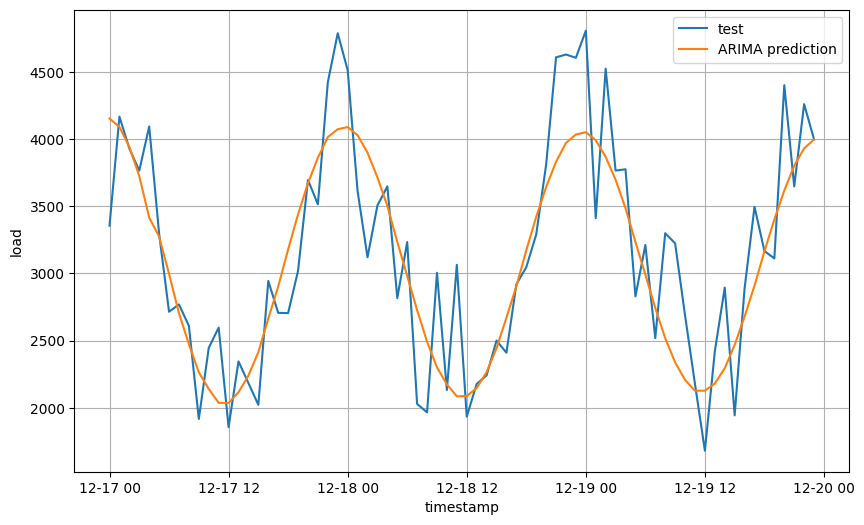

In [ ]:
# покажем на одном графике реальные значения и предсказанные
plt.figure(figsize=(10, 6), dpi=100)
sns.lineplot(x='timestamp', y='load', data=df_test, label='test');
sns.lineplot(x=prediction.index, y=prediction, label='ARIMA prediction');

plt.grid()

С применением ARIMA удалось снизить MAPE по сравнению с Prophet, однако ошибка все еще велика. Возможно, ее получится снизить, если использовать SARIMAX, который учитывает сезонность и внешние факторы, но более перспективным видится применение моделей градиентного бустинга.

**4.3 XGBoost**

Для нахождения оптимальных гиперпараметров XGBoost и других моделей бустинга будем использовать optuna.

Как и ранее для ARIMA, используем валидационную выборку.

Для моделей бустинга временная метка не должна включаться в обучающую выборку (есть категориальные признаки, косвенно указывающие дату) - поэтому удалим признак timestamp.

Стоит отметить, что MAPE для моделей бустинга может несущественно отличаться при разных запусках - даже при фиксированном random_state.

In [ ]:
threshold_date = pd.to_datetime('2024-07-01')
date_train = X_train_scaled['timestamp'] < threshold_date
date_val = X_train_scaled['timestamp'] >= threshold_date

X_train_boost = X_train_scaled[date_train].drop(columns='timestamp')
y_train_boost = y_train[date_train]

X_val_boost = X_train_scaled[date_val].drop(columns='timestamp')
y_val_boost = y_train[date_val]

In [ ]:
import optuna
from sklearn.metrics import mean_absolute_percentage_error
from xgboost import XGBRegressor

def objective(trial):
  # booster = trial.suggest_categorical('booster', ['gbtree', 'gblinear',
  #                                                 'dart'])
  n_estimators = trial.suggest_int('n_estimators', 250, 1500, step=250)
  max_depth = trial.suggest_int('max_depth', 2, 8, step=2)
  learning_rate = trial.suggest_float('learning_rate', 1e-4, 1, log=True)
  xgboost = XGBRegressor(n_estimators=n_estimators, max_depth=max_depth,
                         learning_rate=learning_rate, random_state=42)
  xgboost.fit(X_train_boost, y_train_boost)
  predict = xgboost.predict(X_val_boost)
  score = mean_absolute_percentage_error(y_val_boost, predict)
  return score


study = optuna.create_study(direction='minimize', study_name='XGBoost')
study.optimize(objective, n_trials=100)

xgboost_optuna_score = study.best_value
xgboost_optuna_params = study.best_params

In [ ]:
print(xgboost_optuna_score)
print(xgboost_optuna_params)

# 0.026592593479342078
# {'n_estimators': 1500, 'max_depth': 2, 'learning_rate': 0.5277778061593633}

0.026592593479342078
{'n_estimators': 1500, 'max_depth': 2, 'learning_rate': 0.5277778061593633}


In [ ]:
# обучаем лучшую модель на всей обучающей выборке
xgboost = XGBRegressor(**xgboost_optuna_params)
xgboost.fit(X_train_scaled.drop(columns='timestamp'), y_train)
predict_xgboost = xgboost.predict(X_test_scaled.drop(columns='timestamp'))

mape_xgboost = round((mean_absolute_percentage_error(y_test, predict_xgboost)
              * 100), 3)

mape_xgboost
# 1.641%

1.641

In [ ]:
# добавим результат в датафрейм scores
scores.loc['XGBoost'] = mape_xgboost

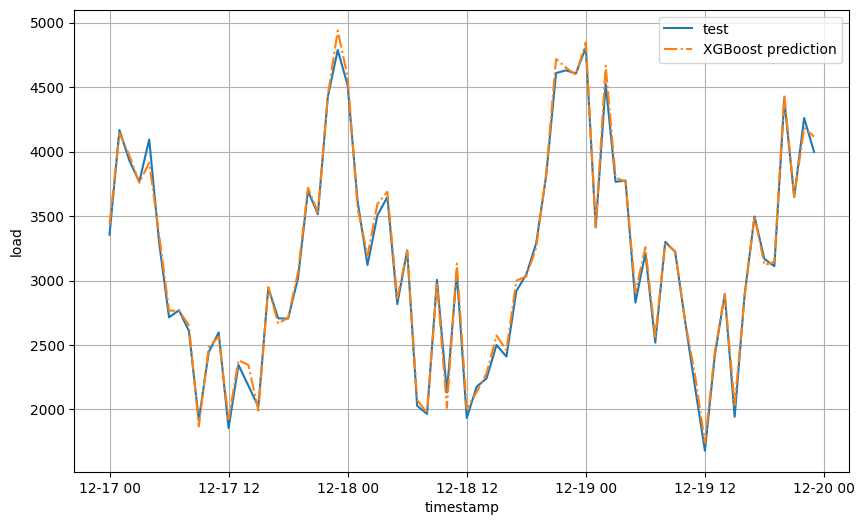

In [ ]:
# покажем на одном графике реальные значения и предсказанные
plt.figure(figsize=(10, 6), dpi=100)
sns.lineplot(x='timestamp', y='load', data=df_test, label='test');
sns.lineplot(x=df_test['timestamp'], y=predict_xgboost, linestyle='-.',
             label='XGBoost prediction');

plt.grid()

XGBoost показывает отличный результат, благодаря чему уже удалось достичь заданного значения MAPE с запасом.

Также попробуем применить LightGBM и CatBoost.

**4.4 LightGBM**

In [ ]:
import optuna
from sklearn.metrics import mean_absolute_percentage_error
from lightgbm import LGBMRegressor

def objective(trial):
  max_depth = trial.suggest_int('max_depth', 2, 10, step=2)
  learning_rate = trial.suggest_float('learning_rate', 1e-4, 1, log=True)
  n_estimators = trial.suggest_int('n_estimators', 1000, 10000, step=1000)
  # убираем вывод лишней информации через verbose=-1
  lgb = LGBMRegressor(num_leaves=2 ** max_depth, max_depth=max_depth,
                      learning_rate=learning_rate, n_estimators=n_estimators,
                      objective='regression', random_state=42, verbose=-1)
  lgb.fit(X_train_boost, y_train_boost)
  predict = lgb.predict(X_val_boost)
  score = mean_absolute_percentage_error(y_val_boost, predict)
  return score


study = optuna.create_study(direction='minimize', study_name='LightGBM')
study.optimize(objective, n_trials=100)

lgb_optuna_score = study.best_value
lgb_optuna_params = study.best_params

In [ ]:
print(lgb_optuna_score)
print(lgb_optuna_params)

# 0.026177039433889607
# {'max_depth': 2, 'learning_rate': 0.34199904041559187, 'n_estimators': 5000}

0.026177039433889607
{'max_depth': 2, 'learning_rate': 0.34199904041559187, 'n_estimators': 5000}


In [ ]:
# обучаем лучшую модель на всей обучающей выборке
lgb = LGBMRegressor(**lgb_optuna_params)
lgb.fit(X_train_scaled.drop(columns='timestamp'), y_train)
predict_lgb = lgb.predict(X_test_scaled.drop(columns='timestamp'))

mape_lgb = round((mean_absolute_percentage_error(y_test, predict_lgb)
              * 100), 3)

mape_lgb
# 1.512%

1.512

In [ ]:
# добавим результат в датафрейм scores
scores.loc['LightGBM'] = mape_lgb

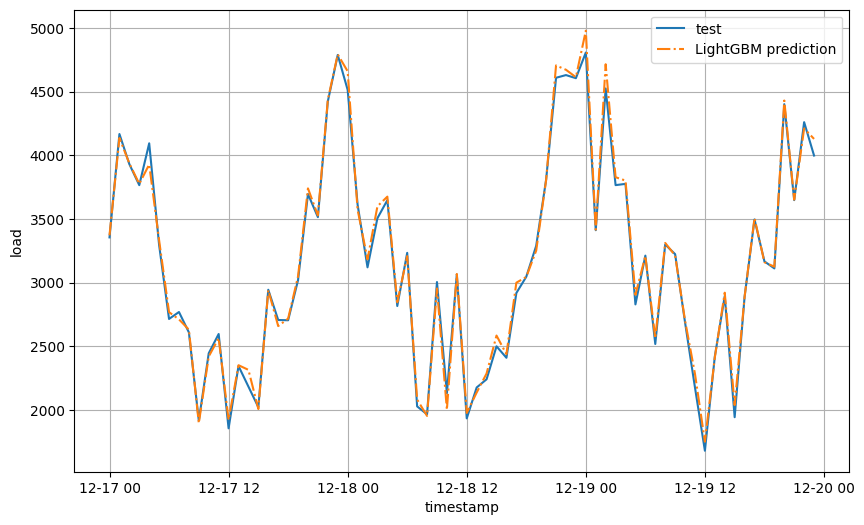

In [ ]:
# покажем на одном графике реальные значения и предсказанные
plt.figure(figsize=(10, 6), dpi=100)
sns.lineplot(x='timestamp', y='load', data=df_test, label='test');
sns.lineplot(x=df_test['timestamp'], y=predict_lgb, linestyle='-.',
             label='LightGBM prediction');

plt.grid()

**4.5 CatBoost**

In [ ]:
import optuna
from sklearn.metrics import mean_absolute_percentage_error
from catboost import CatBoostRegressor

def objective(trial):
  iterations = trial.suggest_int('iterations', 250, 1500, step=250)
  learning_rate = trial.suggest_float('learning_rate', 1e-4, 1, log=True)
  depth = trial.suggest_int('depth', 2, 10, step=2)
  catboost = CatBoostRegressor(iterations=iterations,
                               learning_rate=learning_rate, depth=depth,
                               random_state=42, verbose=False)
  catboost.fit(X_train_boost, y_train_boost)
  predict = catboost.predict(X_val_boost)
  score = mean_absolute_percentage_error(y_val_boost, predict)
  return score


study = optuna.create_study(direction='minimize', study_name='CatBoost')
study.optimize(objective, n_trials=100)

catboost_optuna_score = study.best_value
catboost_optuna_params = study.best_params

[I 2025-12-29 15:56:37,669] A new study created in memory with name: CatBoost
[I 2025-12-29 15:56:41,042] Trial 0 finished with value: 0.026843424882377776 and parameters: {'iterations': 1250, 'learning_rate': 0.19151510920456677, 'depth': 4}. Best is trial 0 with value: 0.026843424882377776.
[I 2025-12-29 15:56:53,876] Trial 1 finished with value: 0.030163903534714463 and parameters: {'iterations': 1500, 'learning_rate': 0.5182418526840575, 'depth': 8}. Best is trial 0 with value: 0.026843424882377776.
[I 2025-12-29 15:57:00,754] Trial 2 finished with value: 0.028841541218520516 and parameters: {'iterations': 1250, 'learning_rate': 0.10525393283836733, 'depth': 2}. Best is trial 0 with value: 0.026843424882377776.
[I 2025-12-29 15:57:06,721] Trial 3 finished with value: 0.23065668678651036 and parameters: {'iterations': 1000, 'learning_rate': 0.00013094543370659664, 'depth': 4}. Best is trial 0 with value: 0.026843424882377776.
[I 2025-12-29 15:57:14,869] Trial 4 finished with value: 

In [ ]:
print(catboost_optuna_score)
print(catboost_optuna_params)

# 0.0266858762406086
# {'iterations': 1000, 'learning_rate': 0.20174188184255998, 'depth': 4}

0.0266858762406086
{'iterations': 1000, 'learning_rate': 0.20174188184255998, 'depth': 4}


In [ ]:
# обучаем лучшую модель на всей обучающей выборке
catboost = CatBoostRegressor(**catboost_optuna_params, verbose=False)
catboost.fit(X_train_scaled.drop(columns='timestamp'), y_train)
predict_catboost = catboost.predict(X_test_scaled.drop(columns='timestamp'))

mape_catboost = round((mean_absolute_percentage_error(y_test, predict_catboost)
              * 100), 3)

mape_catboost
# 1.585%

1.585

In [ ]:
# добавим результат в датафрейм scores
scores.loc['CatBoost'] = mape_catboost

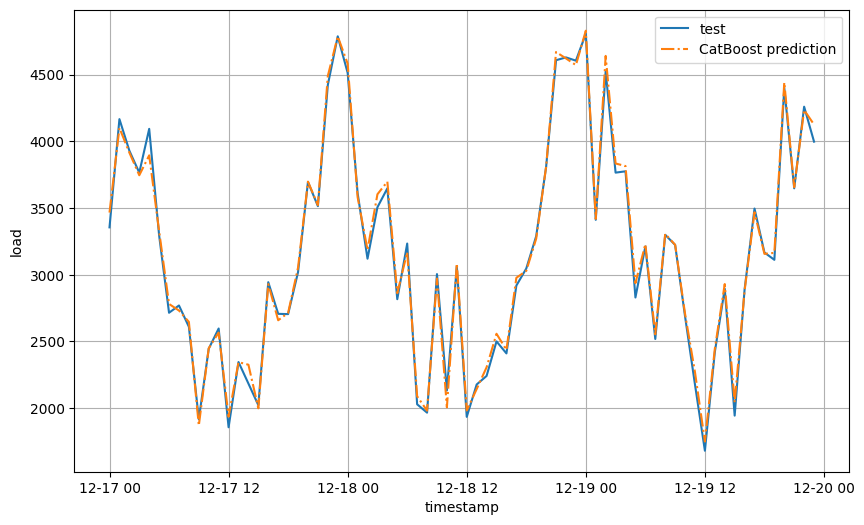

In [ ]:
# покажем на одном графике реальные значения и предсказанные
plt.figure(figsize=(10, 6), dpi=100)
sns.lineplot(x='timestamp', y='load', data=df_test, label='test');
sns.lineplot(x=df_test['timestamp'], y=predict_catboost, linestyle='-.',
             label='CatBoost prediction');

plt.grid()

Итоговые результаты моделей:

In [ ]:
scores

,"MAPE, %"
Prophet,19.469
ARIMA,11.405
XGBoost,1.641
LightGBM,1.512
CatBoost,1.585


# Выводы

Удалось достичь требуемого значения MAPE (с запасом) с помощью алгоритмов градиентного бустинга. Модели бустинга выдают намного лучшие результаты по сравнению с Prophet и ARIMA, при этом между собой показывают сопоставимые значения метрики.

Для дальнейшего повышения точности прогнозов возможно рассмотреть добавление дополнительных погодных признаков (давление, влажность, облачность).